In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

LFC = skewnormal


$$FC = \frac{E[Y|X=1]}{E[Y|X=0]} = \frac{\mu_0 (1-\alpha) + \alpha e^\beta\mu_0}{\mu_0} = 1-\alpha + \alpha e^\beta = 1+\alpha(e^\beta-1)$$

$$LFC = \log \left(1-\alpha + \alpha\beta\right) =  \log \left(1+\alpha(e^\beta-1)\right)$$

<!-- log-fold change = $ \log (1 + \beta  \alpha )$

$LFC = \log(1+\alpha\beta) \iff \frac{\exp(LFC)-1}{\alpha}$ -->


## run simulations


[0.2 0.4 0.6 0.8]


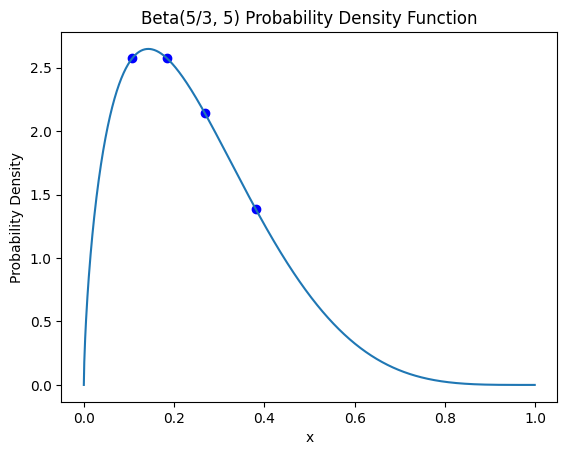

'0.11 0.18 0.27 0.38'

In [2]:
import subprocess
import os

import numpy as np
import scipy
from scipy.stats import beta
import numpy as np

n_guides = 4
quantiles = np.linspace(0, 1, n_guides + 2)[1:-1]
print(quantiles)
beta_samples = scipy.stats.beta.ppf(quantiles, 5 / 3, 5)

x = np.arange(0, 1, 0.001)
pdf = beta.pdf(x, 5 / 3, 5)

plt.plot(x, pdf)
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Beta(5/3, 5) Probability Density Function")

plt.scatter(beta_samples, beta.pdf(beta_samples, 5 / 3, 5), color="blue")
plt.show()

efficiency = " ".join(beta_samples.round(2).astype(str))
efficiency

[0.2 0.4 0.6 0.8]
[0.10778246 0.18399074 0.26800722 0.38139978]


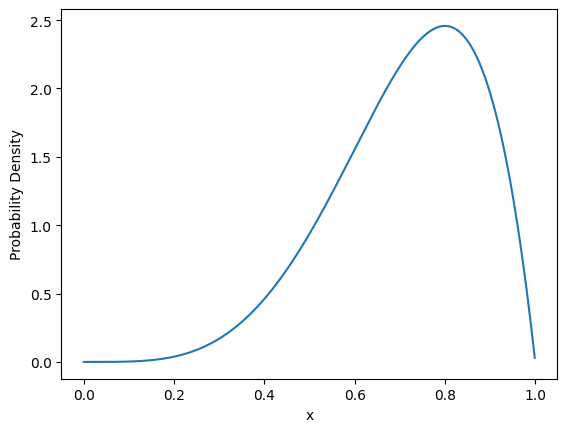

'0.11 0.18 0.27 0.38'

In [3]:
import subprocess
import os

import numpy as np
import scipy
from scipy.stats import beta
import numpy as np

n_guides = 4
quantiles = np.linspace(0, 1, n_guides + 2)[1:-1]
print(quantiles)
efficiency = scipy.stats.beta.ppf(quantiles, 5 / 3, 5)
print(efficiency)

x = np.arange(0, 1, 0.001)
pdf = beta.pdf(x, 5, 2)

plt.plot(x, pdf)
plt.xlabel("x")
plt.ylabel("Probability Density")
# plt.title("Beta(5/3, 5) Probability Density Function")

plt.show()

efficiency_text = " ".join(efficiency.round(2).astype(str))
efficiency_text

In [4]:
efficiency = [0.1, 0.1, 0.9, 0.9]
# efficiency = [0.1, 0.2, 0.5, 0.9]

In [5]:
from perturbo._jax_module import generate_guides_array
import argparse
import os
from typing import Literal, Optional

import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from jax.random import PRNGKey
from numpyro.infer import Predictive
from numpyro.infer.autoguide import AutoNormal, init_to_median
from tensorflow_probability.substrates.jax import distributions as tfd

from perturbo._jax_utils import run_mcmc, run_svi
from perturbo._jax_module import perturbseq_model, perturbseq_guide_autonormal

n_genes = 1  # currently only support single_gene analysis
n_control = 1000
n_guides = len(efficiency)
n_cells_per_guide = 150
n_perturbed = n_guides * n_cells_per_guide
gene_mean = 3
log2_fc = -0.5
gene_disp = 20
# efficiency = 0.3
random_seed = 0
num_samples = 2000
guide_obs = generate_guides_array(n_control=n_control, n_guides=n_guides, n_perturbed=n_perturbed)


def get_unconstrained_locs(svi_result):
    unconstrained_locs = {}
    for k, v in svi_result.params.items():
        param, param_type = k.split("_auto_")
        if param_type == "loc":
            unconstrained_locs[param] = v
    return unconstrained_locs


print("Simulating data with parameters:")
print("# guides:", n_guides)
print("# control cells:", n_control)
print("# perturbed cells:", n_perturbed)
print(f"gene mean, dispersion: {gene_mean:0.2f}, {gene_disp:0.2f}")
print("log_2 fold change:", log2_fc)
print("guide efficiency:", efficiency)

# Define your model parameters
model_params = {
    "guide_obs": guide_obs,
    "log2_fc": jnp.array(log2_fc),
    "efficiency": jnp.array(efficiency).reshape(-1, 1),
    "gene_mean": jnp.array(gene_mean),
    "gene_disp": jnp.array(gene_disp),
}

# Sample data from the prior with frozen values
predictive = Predictive(perturbseq_model, num_samples=1)
samples = predictive(PRNGKey(random_seed), None, **model_params)
gene_obs = samples["gene_obs"][0, ...]

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


Simulating data with parameters:
# guides: 4
# control cells: 1000
# perturbed cells: 600
gene mean, dispersion: 3.00, 20.00
log_2 fold change: -0.5
guide efficiency: [0.1, 0.1, 0.9, 0.9]


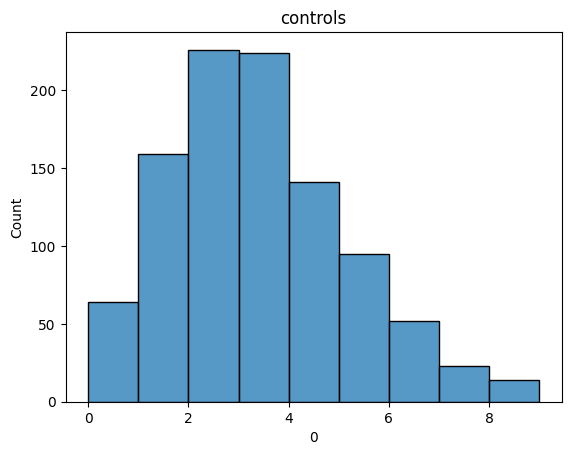

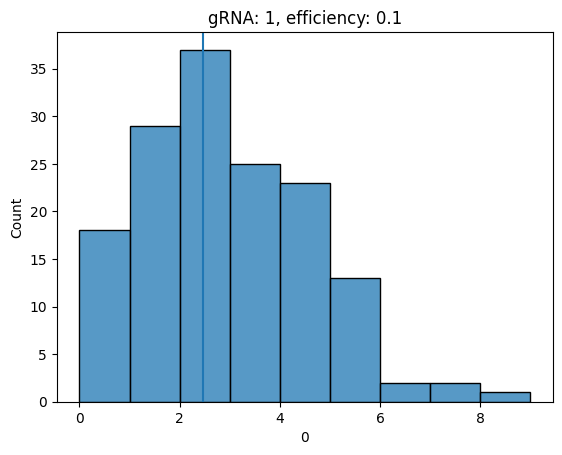

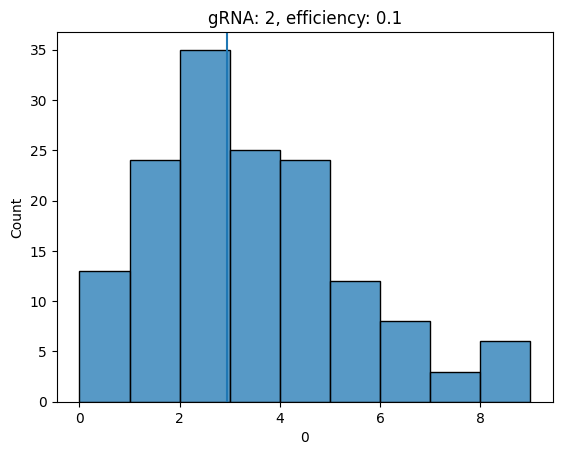

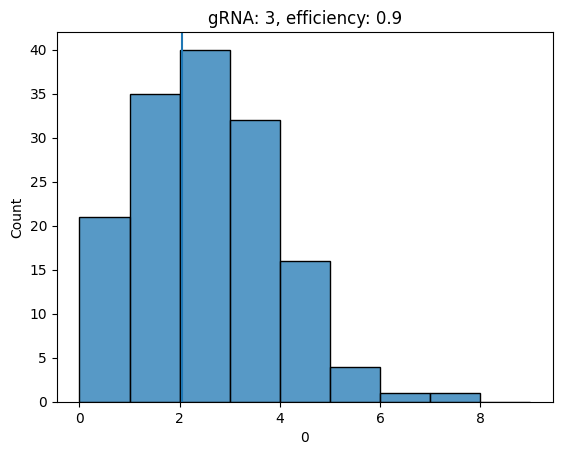

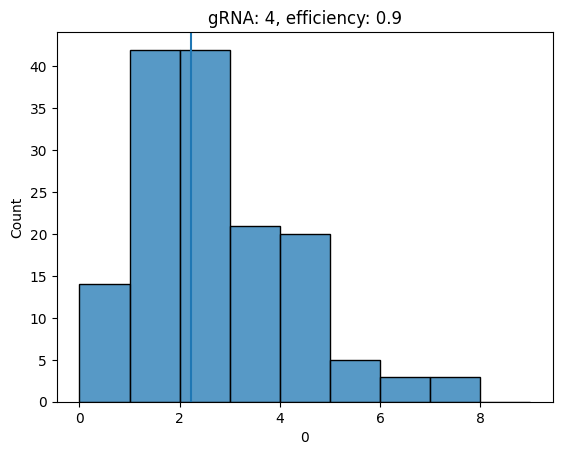

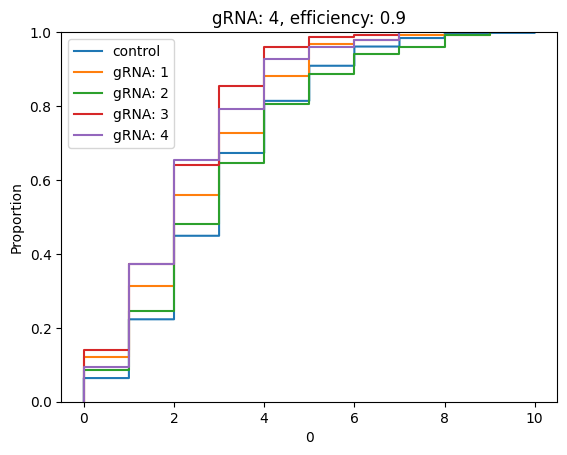

In [6]:
data_df = pd.DataFrame(gene_obs).assign(guide=guide_obs.argmax(axis=1) + (guide_obs.sum(axis=1) > 0))
# guides_df = pd.DataFrame(guide_obs, columns=[f"guide_{i}" for i in range(n_guides)])
# sampled_data = sampled_data
# gene_obs.shape
max_count = data_df.values.max()
counts_col = 0
bins = np.arange(max_count).astype(int)
plt.title("controls")
sns.histplot(data_df.query("guide==0"), x=counts_col, bins=bins)
plt.show()
for guide in range(n_guides):
    plt.title(f"gRNA: {guide+1}, efficiency: {efficiency[guide]:.1f}")
    guide_data = data_df.query(f"guide=={guide+1}")
    plt.axvline(guide_data[counts_col].mean())
    sns.histplot(data_df.query(f"guide=={guide+1}"), x=counts_col, bins=bins)
    plt.show()

sns.ecdfplot(data_df.query("guide==0"), x=counts_col, label="control")
for guide in range(n_guides):
    plt.title(f"gRNA: {guide+1}, efficiency: {efficiency[guide]:.1f}")
    guide_data = data_df.query(f"guide=={guide+1}")
    sns.ecdfplot(guide_data, x=counts_col, label=f"gRNA: {guide+1}")
plt.legend()
plt.show()
# sns.histplot(sampled_data, x="gene_obs")

{'guide_obs': Array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], dtype=float32), 'n_genes': 1}


100%|██████████| 5000/5000 [00:04<00:00, 1160.78it/s, init loss: 10086.7441, avg. loss [4751-5000]: 5599.0027]


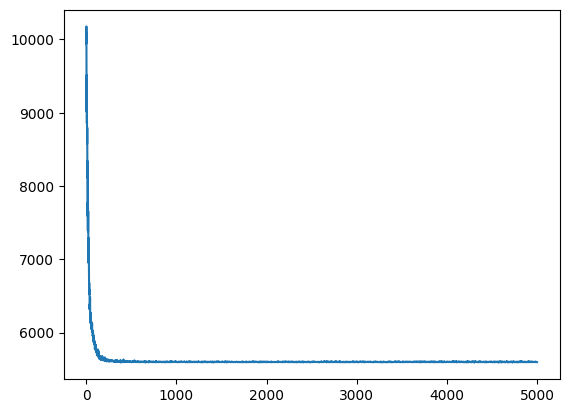

In [7]:
# set model args, kwargs for inference
model_args = (gene_obs,)
model_kwargs = {
    "guide_obs": guide_obs,
    # "efficiency": model_params["efficiency"],
    "n_genes": n_genes,
}
print(model_kwargs)

# construct AutoNormal guide for model
perturbseq_guide = perturbseq_guide_autonormal()
svi_result = run_svi(model_args, model_kwargs, perturbseq_model, perturbseq_guide, random_seed=random_seed)
svi_result.params.keys()
plt.plot(svi_result.losses)

In [8]:
unconstrained_locs = get_unconstrained_locs(svi_result)

# Save SVI results
predictive_svi = Predictive(perturbseq_guide, params=svi_result.params, num_samples=num_samples)
svi_posterior_samples = predictive_svi(PRNGKey(random_seed), None, **model_kwargs)
for k, v in svi_posterior_samples.items():
    print(k, v.shape)

covariate_weights (2000, 1, 1)
dispersion (2000, 1)
efficiency (2000, 4, 1)
log2_fold_change (2000, 1)
mean (2000, 1)


In [9]:
# Save MCMC results
mcmc = run_mcmc(
    model_args,
    model_kwargs,
    perturbseq_model,
    unconstrained_locs,
    num_samples=num_samples,
    random_seed=random_seed,
)
mcmc_posterior_samples = mcmc.get_samples()

sample: 100%|██████████| 3000/3000 [00:14<00:00, 205.52it/s, 15 steps of size 4.60e-01. acc. prob=0.84]


In [10]:
# Create output directories if they don't exist
output_dir = "data/fixed_efficiency"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
jnp.savez(os.path.join(output_dir, "svi"), **svi_posterior_samples)
jnp.savez(os.path.join(output_dir, "mcmc"), **mcmc_posterior_samples)

## load results


In [11]:
# for k in ["log2_fold_change", "mean", "dispersion"]:
# k = "log2_fold_change"


def get_simulation_df(data_dir, k):
    """Read the MCMC and SVI posterior samples from data_dir and return a combined DataFrame for the key k."""
    mcmc_file = f"{data_dir}/mcmc.npz"
    svi_file = f"{data_dir}/svi.npz"
    mcmc_npz = np.load(mcmc_file)
    svi_npz = np.load(svi_file)

    mcmc_df = pd.DataFrame({k: mcmc_npz[k].squeeze(), "method": "MCMC"})
    svi_df = pd.DataFrame({k: svi_npz[k].squeeze(), "method": "SVI"})
    df = pd.concat((mcmc_df, svi_df))
    return df


def get_efficiency_df(data_dir):
    """Read the MCMC and SVI posterior samples from data_dir and return a combined DataFrame for the key k."""
    mcmc_file = f"{data_dir}/mcmc.npz"
    svi_file = f"{data_dir}/svi.npz"
    mcmc_npz = np.load(mcmc_file)
    svi_npz = np.load(svi_file)

    mcmc_data = mcmc_npz["efficiency"].squeeze()
    n_guides = mcmc_data.shape[1]
    guide_names = [f"guide_{i+1}" for i in range(n_guides)]
    mcmc_df = pd.DataFrame(mcmc_npz["efficiency"].squeeze(), columns=guide_names).assign(method="MCMC")
    svi_df = pd.DataFrame(svi_npz["efficiency"].squeeze(), columns=guide_names).assign(method="SVI")
    # mcmc_df = pd.DataFramepd.DataFrame({k: mcmc_npz[k].squeeze(), "method": "MCMC"})
    # svi_df = pd.DataFrame({k: svi_npz[k].squeeze(), "method": "SVI"})
    df = pd.concat((mcmc_df, svi_df))
    return df


lfc_df = get_simulation_df(output_dir, "log2_fold_change")

In [12]:
# dfs = []
#     output_dir = f"data/run_efficiency_{efficiency:0.1f}"
#     lfc_df = get_simulation_df(output_dir, "log2_fold_change")
#     efficiency_df = get_efficiency_df(output_dir)
# lfc_all_df = pd.concat([lfc_df.drop(columns="method"), efficiency_df], axis=1).assign(efficiency=efficiency_text)
lfc_all_df = lfc_df.assign(efficiency=efficiency_text)
lfc_all_df
#     dfs.append(combined_df)
# lfc_all_df = pd.concat(dfs)

,log2_fold_change,method,efficiency
0,-0.626819,MCMC,0.11 0.18 0.27 0.38
1,-0.326675,MCMC,0.11 0.18 0.27 0.38
2,-0.478243,MCMC,0.11 0.18 0.27 0.38
3,-0.429536,MCMC,0.11 0.18 0.27 0.38
4,-0.639709,MCMC,0.11 0.18 0.27 0.38
...,...,...,...
1995,-0.450626,SVI,0.11 0.18 0.27 0.38
1996,-0.447413,SVI,0.11 0.18 0.27 0.38
1997,-0.414043,SVI,0.11 0.18 0.27 0.38
1998,-0.407642,SVI,0.11 0.18 0.27 0.38


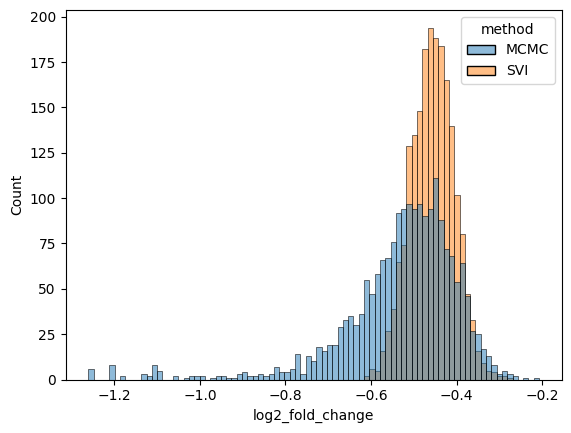

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

n_bins = 100

# g = sns.FacetGrid(lfc_all_df hue="method", height=3, aspect=2, sharex=False)
sns.histplot(lfc_all_df, x="log2_fold_change", hue="method", alpha=0.5)
# Add a legend
# g.add_legend()

plt.show()